# TripletNet1: Hierarchical CLIP-frame triplet encoder

This notebook trains the model with **5-fold artist-disjoint cross-validation** and then runs a thesis-oriented post-training analysis suite. The quantitative analysis prioritizes out-of-fold validation predictions; the latent-space and nearest-neighbour sections are used for interpretability and qualitative diagnosis.


> Note: `TripletNet1` is the registered hierarchical Transformer in `model.py`: frame projection, learned positional encoding, frame-level Transformer, per-video mean pooling, masked artist-level Transformer, masked mean pooling, projection head, BNNeck, and L2 normalization. Previous saved outputs were cleared because they came from an older training protocol.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from cv_training import (
    FoldTrainingConfig,
    TRIPLET_COLUMNS,
    make_artist_disjoint_kfold_splits,
    run_one_fold_margin,
    summarize_cv_results,
)
from dataset import filter_triplets, process_artists
from model import MODEL_REGISTRY
from utils import set_seed


In [2]:
SEED = 3407
set_seed(SEED)

MODEL_NAME = "TripletNet1"
MODEL_CLASS = MODEL_REGISTRY[MODEL_NAME]

BASE_DIR = Path("../data/video_embeddings")
TRIPLETS_CSV = Path("../data/triplets/triplets_ids_music_spot.csv")
OUTPUT_DIR = Path("checkpoints") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = Path("figures") / MODEL_NAME.lower().replace("tripletnet", "model")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str) -> Path:
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
NUM_EPOCHS = 30
N_FOLDS = 5
NUM_WORKERS = 0
OPTIMIZER = "adamw"
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 8
MARGINS = [0.1, 0.3, 0.5, 0.7, 0.9]

print(f"Using device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"5-fold CV with {N_FOLDS} artist-disjoint folds")
print(f"fixed CSV negatives | margin grid={MARGINS} | optimizer={OPTIMIZER} | batch_size={BATCH_SIZE} | lr={LEARNING_RATE:.1e} | weight_decay={WEIGHT_DECAY:.1e}")


Using device: cuda
Model: TripletNet1
5-fold CV with 5 artist-disjoint folds
fixed CSV negatives | margin grid=[0.1, 0.3, 0.5, 0.7, 0.9] | optimizer=adamw | batch_size=128 | lr=2.0e-04 | weight_decay=1.0e-05


In [3]:
ARTIST_AGGREGATION = "stack"
MAX_VIDEOS = 10
NUM_FRAMES = 30
VIDEO_DROPOUT = 0.15

artist_averages = process_artists(
    BASE_DIR,
    aggregation=ARTIST_AGGREGATION,
    max_videos=MAX_VIDEOS,
    num_frames=NUM_FRAMES,
    keep_most_common_shape=True,
)

if not artist_averages:
    raise RuntimeError(f"No artist embeddings found under {BASE_DIR!s}. Check BASE_DIR.")

sample_embedding = next(iter(artist_averages.values()))

if sample_embedding.ndim == 3:
    MAX_VIDEOS_ACTUAL = int(sample_embedding.shape[0])
    SEQ_LEN = int(sample_embedding.shape[1])
    D_MODEL = int(sample_embedding.shape[2])
    MODEL_KWARGS = {
        "d_model": D_MODEL,
        "seq_len": SEQ_LEN,
        "max_videos": MAX_VIDEOS_ACTUAL,
        "video_dropout_p": VIDEO_DROPOUT,
    }
elif sample_embedding.ndim == 2:
    SEQ_LEN = int(sample_embedding.shape[0])
    D_MODEL = int(sample_embedding.shape[1])
    MODEL_KWARGS = {
        "d_model": D_MODEL,
        "seq_len": SEQ_LEN,
        "video_dropout_p": VIDEO_DROPOUT,
    }
else:
    raise ValueError(f"Unexpected artist embedding shape: {tuple(sample_embedding.shape)}")

raw_triplet_df = pd.read_csv(TRIPLETS_CSV)
filtered_triplet_df = filter_triplets(raw_triplet_df, artist_averages)

if filtered_triplet_df.empty:
    raise RuntimeError("No usable triplets after filtering. Check triplet CSV IDs and embedding folders.")

folds = make_artist_disjoint_kfold_splits(filtered_triplet_df, n_splits=N_FOLDS, seed=SEED)
fold_stats_df = pd.DataFrame([stats for _, _, _, stats in folds])

print(f"Artists with embeddings: {len(artist_averages)}")
print(f"Filtered triplets: {len(filtered_triplet_df)}")
print(f"Sample embedding shape: {tuple(sample_embedding.shape)}")
print(f"MODEL_KWARGS: {MODEL_KWARGS}")
display(fold_stats_df)


Artists with embeddings: 3892
Filtered triplets: 27350
Sample embedding shape: (10, 30, 768)
MODEL_KWARGS: {'d_model': 768, 'seq_len': 30, 'max_videos': 10, 'video_dropout_p': 0.15}


,fold,strategy,train_rows,val_rows,dropped_cross_partition_rows,kept_row_ratio,train_artists,val_artists,train_artist_partition_size,val_artist_partition_size,anchor_overlap,artist_overlap
0,1,artist_disjoint_kfold,14117,228,13005,0.524497,2404,375,2405,602,False,False
1,2,artist_disjoint_kfold,13790,235,13325,0.512797,2405,378,2405,602,False,False
2,3,artist_disjoint_kfold,14337,218,12795,0.532176,2405,365,2406,601,False,False
3,4,artist_disjoint_kfold,14060,216,13074,0.521974,2406,366,2406,601,False,False
4,5,artist_disjoint_kfold,13837,235,13278,0.514516,2406,384,2406,601,False,False


In [4]:
training_config = FoldTrainingConfig(
    model_name=MODEL_NAME,
    model_class=MODEL_CLASS,
    model_kwargs=MODEL_KWARGS,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    num_epochs=NUM_EPOCHS,
    optimizer_name=OPTIMIZER,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    distance_fn="cosine",
    grad_clip=1.0,
)


def make_model():
    return MODEL_CLASS(**MODEL_KWARGS).to(DEVICE)


In [5]:
results = []

for margin in MARGINS:
    for fold_id, train_df, val_df, fold_stats in folds:
        print("=" * 100)
        print(
            f"Training {MODEL_NAME}: fixed CSV negatives, "
            f"margin={margin:.2f}, fold={fold_id}/{N_FOLDS} | "
            f"train_rows={fold_stats['train_rows']} | val_rows={fold_stats['val_rows']}"
        )
        results.append(
            run_one_fold_margin(
                fold_id,
                train_df,
                val_df,
                margin,
                artist_averages,
                training_config,
            )
        )

fold_summary_df, margin_summary_df = summarize_cv_results(results, OUTPUT_DIR, MODEL_NAME)

display(fold_summary_df)
display(margin_summary_df)


Training TripletNet1: fixed CSV negatives, margin=0.10, fold=1/5 | train_rows=14117 | val_rows=228
fold=1 | fixed CSV negatives | margin=0.10 | epoch=001/30 | train_loss=0.04571 | train_acc=89.25% | val_loss=0.04144 | val_mrr=0.2915 | val_acc=91.23% | val_margin_acc=84.21% | lr=2.00e-04
fold=1 | fixed CSV negatives | margin=0.10 | epoch=002/30 | train_loss=0.02740 | train_acc=93.79% | val_loss=0.05398 | val_mrr=0.3003 | val_acc=89.91% | val_margin_acc=85.96% | lr=2.00e-04
fold=1 | fixed CSV negatives | margin=0.10 | epoch=003/30 | train_loss=0.01977 | train_acc=95.61% | val_loss=0.04383 | val_mrr=0.3153 | val_acc=89.04% | val_margin_acc=87.28% | lr=2.00e-04
fold=1 | fixed CSV negatives | margin=0.10 | epoch=004/30 | train_loss=0.01564 | train_acc=96.62% | val_loss=0.04197 | val_mrr=0.3096 | val_acc=92.11% | val_margin_acc=85.96% | lr=2.00e-04
fold=1 | fixed CSV negatives | margin=0.10 | epoch=005/30 | train_loss=0.01364 | train_acc=97.00% | val_loss=0.04360 | val_mrr=0.3082 | val_acc=9

,model,margin,optimizer,fold,best_epoch,epochs_ran,best_val_mrr,best_val_acc,best_val_margin_acc,best_val_loss,checkpoint_path,history_path
0,TripletNet1,0.1,adamw,1,13,21,0.339273,0.894737,0.864035,0.043342,checkpoints/TripletNet1/TripletNet1_margin_0.1...,checkpoints/TripletNet1/TripletNet1_margin_0.1...
1,TripletNet1,0.1,adamw,2,5,13,0.296765,0.893617,0.872340,0.040592,checkpoints/TripletNet1/TripletNet1_margin_0.1...,checkpoints/TripletNet1/TripletNet1_margin_0.1...
2,TripletNet1,0.1,adamw,3,5,13,0.326994,0.917431,0.880734,0.048898,checkpoints/TripletNet1/TripletNet1_margin_0.1...,checkpoints/TripletNet1/TripletNet1_margin_0.1...
3,TripletNet1,0.1,adamw,4,12,20,0.310170,0.921296,0.916667,0.033125,checkpoints/TripletNet1/TripletNet1_margin_0.1...,checkpoints/TripletNet1/TripletNet1_margin_0.1...
4,TripletNet1,0.1,adamw,5,5,13,0.284017,0.897872,0.863830,0.048518,checkpoints/TripletNet1/TripletNet1_margin_0.1...,checkpoints/TripletNet1/TripletNet1_margin_0.1...
5,TripletNet1,0.3,adamw,1,9,17,0.342844,0.890351,0.780702,0.096438,checkpoints/TripletNet1/TripletNet1_margin_0.3...,checkpoints/TripletNet1/TripletNet1_margin_0.3...
6,TripletNet1,0.3,adamw,2,3,11,0.287563,0.931915,0.812766,0.074338,checkpoints/TripletNet1/TripletNet1_margin_0.3...,checkpoints/TripletNet1/TripletNet1_margin_0.3...
7,TripletNet1,0.3,adamw,3,7,15,0.296978,0.917431,0.775229,0.096802,checkpoints/TripletNet1/TripletNet1_margin_0.3...,checkpoints/TripletNet1/TripletNet1_margin_0.3...
8,TripletNet1,0.3,adamw,4,8,16,0.337022,0.925926,0.842593,0.080346,checkpoints/TripletNet1/TripletNet1_margin_0.3...,checkpoints/TripletNet1/TripletNet1_margin_0.3...
9,TripletNet1,0.3,adamw,5,3,11,0.289659,0.910638,0.727660,0.110376,checkpoints/TripletNet1/TripletNet1_margin_0.3...,checkpoints/TripletNet1/TripletNet1_margin_0.3...


,model,optimizer,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_margin_acc,std_best_val_margin_acc,mean_best_val_loss,std_best_val_loss,mean_best_epoch,mean_epochs_ran
0,TripletNet1,adamw,0.1,0.311444,0.022280,0.904991,0.013284,0.879521,0.021902,0.042895,0.006492,8.0,16.0
1,TripletNet1,adamw,0.3,0.310813,0.026890,0.915252,0.016107,0.787790,0.043159,0.091660,0.014384,6.0,14.0
2,TripletNet1,adamw,0.5,0.298374,0.018197,0.910158,0.012207,0.674386,0.054981,0.161151,0.022604,6.8,14.8
3,TripletNet1,adamw,0.7,0.271555,0.021331,0.905035,0.019967,0.554823,0.065789,0.260761,0.024203,8.4,16.4
4,TripletNet1,adamw,0.9,0.260653,0.014763,0.897008,0.016863,0.445706,0.025965,0.368816,0.027751,6.6,14.6



## Post-training analysis plan

After the 5-fold training finishes, this notebook reports the model from three complementary angles:

1. **Generalisation and stability**: compare margins across folds, inspect training/validation curves, and optionally compare all five model notebooks if their summary files exist.
2. **Triplet-learning quality**: aggregate out-of-fold validation predictions, then analyse positive vs negative cosine similarity, margin gaps, ranking accuracy, margin-satisfied accuracy, and threshold precision/recall/F1.
3. **Retrieval and latent-space usefulness**: use the selected best checkpoint to embed artists, compute nearest-neighbour retrieval metrics, inspect qualitative neighbours/errors, and visualise/diagnose the latent space using metadata when available.

The out-of-fold triplet analysis is the primary quantitative evidence because every prediction is made by a model that did not train on that fold's anchor artists. The latent-space plots and nearest-neighbour examples are interpretability checks, not the sole performance evidence.


In [6]:

import math
import warnings
from collections import defaultdict

import torch.nn.functional as F

ANALYSIS_DIR = OUTPUT_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Select the best margin by mean 5-fold validation MRR. Ties prefer higher ranking accuracy, then lower loss.
best_margin = float(margin_summary_df.iloc[0]["margin"])
best_margin_results = sorted(
    [item for item in results if float(item["margin"]) == best_margin],
    key=lambda item: int(item["fold"]),
)
best_fold_result = max(
    best_margin_results,
    key=lambda item: (item["best_val_mrr"], item["best_val_acc"], -item["best_val_loss"]),
)


def load_model_from_checkpoint(checkpoint_path: str | Path):
    checkpoint_path = Path(checkpoint_path)
    model = make_model()
    state = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


def encode_triplet_distances(model, triplets, fold: int | None = None, margin: float | None = None) -> pd.DataFrame:
    rows = []
    model.eval()
    margin = best_margin if margin is None else float(margin)
    with torch.inference_mode():
        for idx, (anchor, positive, negative) in enumerate(triplets):
            anchor_input = anchor.unsqueeze(0).to(DEVICE).float()
            positive_input = positive.unsqueeze(0).to(DEVICE).float()
            negative_input = negative.unsqueeze(0).to(DEVICE).float()

            anchor_emb, positive_emb, negative_emb = model(anchor_input, positive_input, negative_input)
            positive_similarity = F.cosine_similarity(anchor_emb, positive_emb, dim=1).item()
            negative_similarity = F.cosine_similarity(anchor_emb, negative_emb, dim=1).item()
            positive_distance = 1.0 - positive_similarity
            negative_distance = 1.0 - negative_similarity
            margin_gap = negative_distance - positive_distance

            rows.append({
                "fold": fold,
                "triplet_id": idx,
                "positive_similarity": positive_similarity,
                "negative_similarity": negative_similarity,
                "positive_distance": positive_distance,
                "negative_distance": negative_distance,
                "similarity_gap": positive_similarity - negative_similarity,
                "margin_gap": margin_gap,
                "ranking_correct": positive_distance < negative_distance,
                "margin_satisfied": positive_distance + margin < negative_distance,
            })
    return pd.DataFrame(rows)


def build_oof_triplet_predictions() -> pd.DataFrame:
    frames = []
    for item in best_margin_results:
        fold_model = load_model_from_checkpoint(item["checkpoint_path"])
        fold_df = encode_triplet_distances(
            fold_model,
            item["val_triplets"],
            fold=int(item["fold"]),
            margin=float(item["margin"]),
        )
        fold_df["model"] = item["model"]
        fold_df["margin"] = float(item["margin"])
        fold_df["checkpoint_path"] = item["checkpoint_path"]
        frames.append(fold_df)
    if not frames:
        raise RuntimeError("No validation predictions were generated. Check results/best_margin_results.")
    return pd.concat(frames, ignore_index=True)


def pair_threshold_curve(oof_df: pd.DataFrame, thresholds: np.ndarray | None = None) -> pd.DataFrame:
    if thresholds is None:
        min_score = float(min(oof_df["positive_similarity"].min(), oof_df["negative_similarity"].min()))
        max_score = float(max(oof_df["positive_similarity"].max(), oof_df["negative_similarity"].max()))
        lower = max(-1.0, math.floor(min_score * 100) / 100)
        upper = min(1.0, math.ceil(max_score * 100) / 100)
        thresholds = np.linspace(lower, upper, 101)

    pos_scores = oof_df["positive_similarity"].to_numpy(dtype=float)
    neg_scores = oof_df["negative_similarity"].to_numpy(dtype=float)
    rows = []
    for threshold in thresholds:
        tp = int((pos_scores >= threshold).sum())
        fn = int((pos_scores < threshold).sum())
        fp = int((neg_scores >= threshold).sum())
        tn = int((neg_scores < threshold).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "threshold": float(threshold),
            "precision": precision,
            "recall": recall,
            "specificity": specificity,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        })
    return pd.DataFrame(rows)


def safe_auc_metrics(oof_df: pd.DataFrame) -> dict[str, float]:
    y_true = np.concatenate([
        np.ones(len(oof_df), dtype=int),
        np.zeros(len(oof_df), dtype=int),
    ])
    y_score = np.concatenate([
        oof_df["positive_similarity"].to_numpy(dtype=float),
        oof_df["negative_similarity"].to_numpy(dtype=float),
    ])
    out = {"roc_auc": float("nan"), "average_precision": float("nan")}
    try:
        from sklearn.metrics import average_precision_score, roc_auc_score
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
        out["average_precision"] = float(average_precision_score(y_true, y_score))
    except Exception as exc:
        warnings.warn(f"sklearn metrics unavailable; ROC-AUC/AP skipped: {exc}")
    return out


oof_triplet_df = build_oof_triplet_predictions()
threshold_metrics_df = pair_threshold_curve(oof_triplet_df)
best_threshold_row = threshold_metrics_df.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0]
auc_metrics = safe_auc_metrics(oof_triplet_df)

best_model = load_model_from_checkpoint(best_fold_result["checkpoint_path"])
best_checkpoint_path = Path(best_fold_result["checkpoint_path"])

print(f"Best margin by 5-fold mean validation MRR: {best_margin:.2f}")
print(f"Best single fold checkpoint for embedding-level analysis: fold={best_fold_result['fold']} -> {best_checkpoint_path}")
print(f"Out-of-fold validation triplets: {len(oof_triplet_df)}")
print(f"OOF ranking accuracy: {oof_triplet_df['ranking_correct'].mean():.2%}")
print(f"OOF margin-satisfied accuracy: {oof_triplet_df['margin_satisfied'].mean():.2%}")
print(f"Best threshold by F1: {best_threshold_row['threshold']:.3f}")
print(f"ROC-AUC: {auc_metrics['roc_auc']:.4f} | Average precision: {auc_metrics['average_precision']:.4f}")

display(oof_triplet_df.describe())
display(threshold_metrics_df.sort_values("f1", ascending=False).head(10))


Best margin by 5-fold mean validation MRR: 0.10
Best single fold checkpoint for embedding-level analysis: fold=1 -> checkpoints/TripletNet1/TripletNet1_margin_0.10_fold_1_best.pt
Out-of-fold validation triplets: 1132
OOF ranking accuracy: 90.46%
OOF margin-satisfied accuracy: 87.90%
Best threshold by F1: 0.273
ROC-AUC: 0.9254 | Average precision: 0.9127


,fold,triplet_id,positive_similarity,negative_similarity,positive_distance,negative_distance,similarity_gap,margin_gap,margin
count,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1132.000000,1.132000e+03
mean,2.995583,112.845406,0.581994,0.005110,0.418006,0.994890,0.576884,0.576884,1.000000e-01
std,1.426966,65.634629,0.245150,0.277857,0.245150,0.277857,0.380357,0.380357,1.388392e-17
min,1.000000,0.000000,-0.391692,-0.572215,0.000000,0.000000,-1.152985,-1.152985,1.000000e-01
25%,2.000000,56.000000,0.441350,-0.189602,0.231545,0.829238,0.346629,0.346629,1.000000e-01
50%,3.000000,113.000000,0.633801,-0.040286,0.366199,1.040286,0.619294,0.619294,1.000000e-01
75%,4.000000,169.000000,0.768455,0.170762,0.558650,1.189602,0.866115,0.866115,1.000000e-01
max,5.000000,234.000000,1.000000,1.000000,1.391692,1.572215,1.389999,1.389999,1.000000e-01


,threshold,precision,recall,specificity,f1,tp,fp,fn,tn
54,0.2732,0.836838,0.878975,0.828622,0.857389,995,194,137,938
52,0.2416,0.825696,0.891343,0.811837,0.857264,1009,213,123,919
50,0.2100,0.810386,0.909894,0.787102,0.857262,1030,241,102,891
53,0.2574,0.830705,0.884276,0.819788,0.856654,1001,204,131,928
55,0.2890,0.841432,0.871908,0.835689,0.856399,987,186,145,946
51,0.2258,0.818548,0.896643,0.801237,0.855818,1015,225,117,907
56,0.3048,0.846620,0.863074,0.843640,0.854768,977,177,155,955
57,0.3206,0.852604,0.853357,0.852473,0.852980,966,167,166,965
49,0.1942,0.799691,0.913428,0.771201,0.852784,1034,259,98,873
59,0.3522,0.869806,0.832155,0.875442,0.850564,942,141,190,991


### 1. Cross-validation stability and cross-model comparison


,model,optimizer,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_margin_acc,std_best_val_margin_acc,mean_best_val_loss,std_best_val_loss,mean_best_epoch,mean_epochs_ran
0,TripletNet1,adamw,0.1,0.311444,0.022280,0.904991,0.013284,0.879521,0.021902,0.042895,0.006492,8.0,16.0
1,TripletNet1,adamw,0.3,0.310813,0.026890,0.915252,0.016107,0.787790,0.043159,0.091660,0.014384,6.0,14.0
2,TripletNet1,adamw,0.5,0.298374,0.018197,0.910158,0.012207,0.674386,0.054981,0.161151,0.022604,6.8,14.8
3,TripletNet1,adamw,0.7,0.271555,0.021331,0.905035,0.019967,0.554823,0.065789,0.260761,0.024203,8.4,16.4
4,TripletNet1,adamw,0.9,0.260653,0.014763,0.897008,0.016863,0.445706,0.025965,0.368816,0.027751,6.6,14.6


Saved figure: figures/model1/margin_sensitivity.png


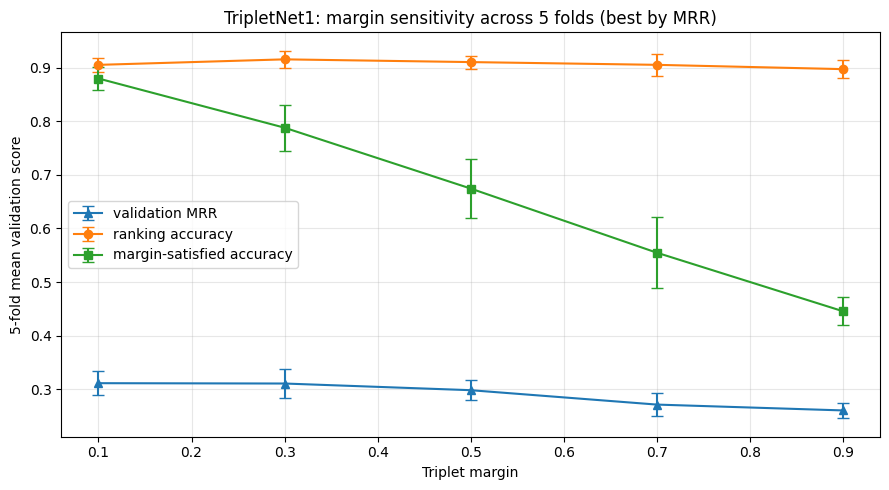

Saved figure: figures/model1/cv_history_margin_0.10.png


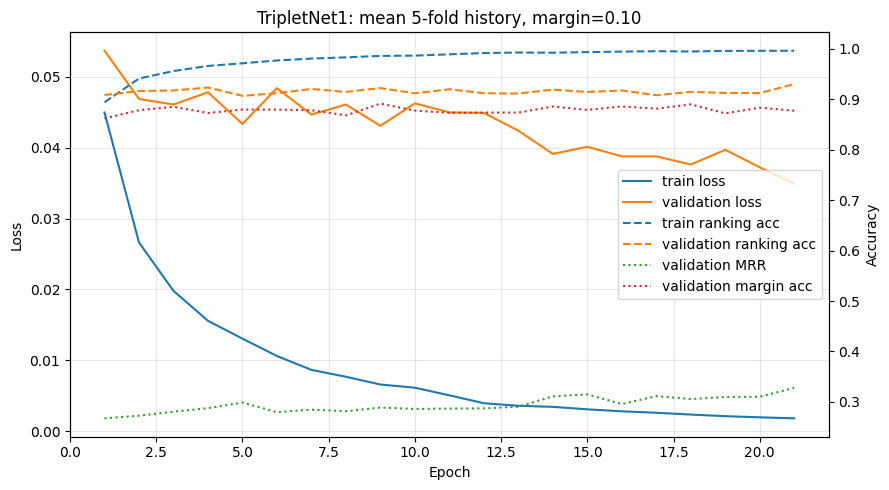

,epoch,train_loss,val_loss,val_mrr,train_acc,val_acc,val_margin_acc,mean_pos_dist,mean_neg_dist
16,17,0.002592,0.038784,0.311426,0.995100,0.907895,0.881213,0.410775,1.016378
17,18,0.002338,0.037631,0.305741,0.994569,0.914596,0.889742,0.410179,1.015170
18,19,0.002110,0.039706,0.309807,0.995704,0.912403,0.871954,0.406599,1.017214
19,20,0.001950,0.037232,0.310287,0.995884,0.912159,0.883163,0.409138,1.017231
20,21,0.001805,0.034942,0.327798,0.996104,0.929825,0.877193,0.421435,1.015865


,model,margin,mean_best_val_mrr,std_best_val_mrr,mean_best_val_acc,std_best_val_acc,mean_best_val_loss,mean_best_val_margin_acc
0,TripletNet1,0.1,0.311444,0.02228,0.904991,0.013284,0.042895,0.879521


Saved figure: figures/model1/cross_model_best_validation_mrr.png


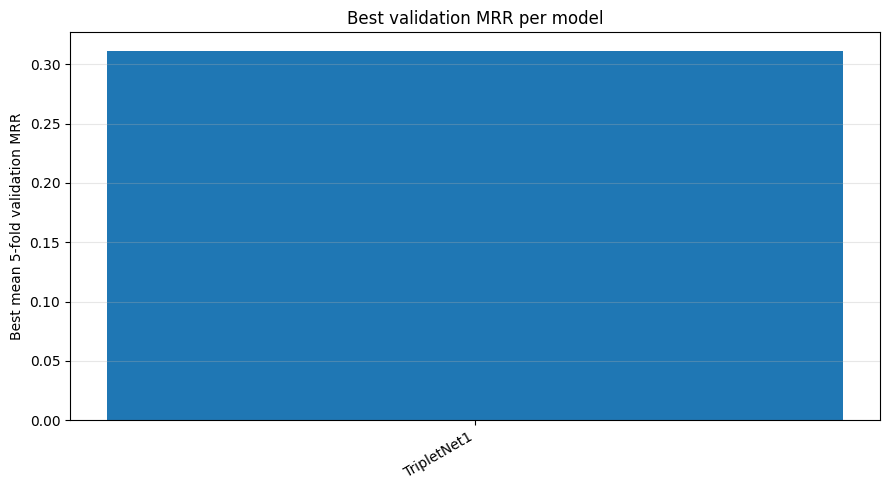

In [7]:
# 1) Cross-validation stability: margin ranking and training curves.
cv_display = margin_summary_df.copy()
for col in [
    "mean_best_val_mrr",
    "std_best_val_mrr",
    "mean_best_val_acc",
    "std_best_val_acc",
    "mean_best_val_margin_acc",
    "std_best_val_margin_acc",
]:
    if col in cv_display.columns:
        cv_display[col] = cv_display[col].astype(float)

display(cv_display)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_mrr"].astype(float),
    yerr=cv_display["std_best_val_mrr"].fillna(0).astype(float),
    marker="^",
    capsize=4,
    label="validation MRR",
)
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_acc"].astype(float),
    yerr=cv_display["std_best_val_acc"].fillna(0).astype(float),
    marker="o",
    capsize=4,
    label="ranking accuracy",
)
ax.errorbar(
    cv_display["margin"].astype(float),
    cv_display["mean_best_val_margin_acc"].astype(float),
    yerr=cv_display["std_best_val_margin_acc"].fillna(0).astype(float),
    marker="s",
    capsize=4,
    label="margin-satisfied accuracy",
)
ax.set_xlabel("Triplet margin")
ax.set_ylabel("5-fold mean validation score")
ax.set_title(f"{MODEL_NAME}: margin sensitivity across 5 folds (best by MRR)")
ax.grid(True, alpha=0.3)
ax.legend()
save_figure(fig, "margin_sensitivity.png")
plt.show()


def plot_cv_history_for_margin(results: list[dict], margin: float):
    histories = [item["history"] for item in results if float(item["margin"]) == float(margin)]
    if not histories:
        raise ValueError(f"No histories found for margin={margin}")
    combined = pd.concat(histories, ignore_index=True)
    agg_spec = {
        "train_loss": ("train_loss", "mean"),
        "val_loss": ("val_loss", "mean"),
        "val_mrr": ("val_mrr", "mean"),
        "train_acc": ("train_acc", "mean"),
        "val_acc": ("val_acc", "mean"),
        "val_margin_acc": ("val_margin_acc", "mean"),
    }
    for metric in ["mean_pos_dist", "mean_neg_dist"]:
        if metric in combined.columns:
            agg_spec[metric] = (metric, "mean")
    cv_history = combined.groupby("epoch", as_index=False).agg(**agg_spec)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(cv_history["epoch"], cv_history["train_loss"], label="train loss")
    ax1.plot(cv_history["epoch"], cv_history["val_loss"], label="validation loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(cv_history["epoch"], cv_history["train_acc"], linestyle="--", label="train ranking acc")
    ax2.plot(cv_history["epoch"], cv_history["val_acc"], linestyle="--", label="validation ranking acc")
    ax2.plot(cv_history["epoch"], cv_history["val_mrr"], linestyle=":", label="validation MRR")
    ax2.plot(cv_history["epoch"], cv_history["val_margin_acc"], linestyle=":", label="validation margin acc")
    ax2.set_ylabel("Accuracy")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="center right")
    ax1.set_title(f"{MODEL_NAME}: mean 5-fold history, margin={margin:.2f}")
    save_figure(fig, f"cv_history_margin_{margin:.2f}.png")
    plt.show()


    return cv_history

cv_history_df = plot_cv_history_for_margin(results, best_margin)
display(cv_history_df.tail())

# Optional cross-notebook comparison. This becomes useful after running model1.ipynb ... model4.ipynb.
def load_available_model_summaries(root: Path = Path("checkpoints")) -> pd.DataFrame:
    frames = []
    for path in sorted(root.glob("TripletNet*/TripletNet*_5fold_margin_summary.csv")):
        try:
            df = pd.read_csv(path)
            df["summary_path"] = str(path)
            frames.append(df)
        except Exception as exc:
            print(f"Skipping {path}: {exc}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

all_model_summaries = load_available_model_summaries()
if not all_model_summaries.empty and "mean_best_val_mrr" not in all_model_summaries.columns:
    print("Existing summaries do not contain validation MRR yet. Re-run all model notebooks after this update.")
    all_model_summaries = pd.DataFrame()
if not all_model_summaries.empty:
    if "margin" in all_model_summaries.columns:
        all_model_summaries = all_model_summaries.loc[
            all_model_summaries["margin"].astype(float).isin(MARGINS)
        ].copy()
if all_model_summaries.empty:
    print(
        f"No cross-model summaries found for fixed CSV negatives and margins={MARGINS}. "
        "Run the other model notebooks to enable model-level comparison."
    )
else:
    best_per_model = (
        all_model_summaries.sort_values(["model", "mean_best_val_mrr", "mean_best_val_acc", "mean_best_val_loss"], ascending=[True, False, False, True])
        .groupby("model", as_index=False)
        .head(1)
        .sort_values("mean_best_val_mrr", ascending=False)
        .reset_index(drop=True)
    )
    display_cols = [
        col for col in [
            "model",
            "margin",
            "mean_best_val_mrr",
            "std_best_val_mrr",
            "mean_best_val_acc",
            "std_best_val_acc",
            "mean_best_val_loss",
            "mean_best_val_margin_acc",
                                ]
        if col in best_per_model.columns
    ]
    display(best_per_model[display_cols])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(best_per_model["model"], best_per_model["mean_best_val_mrr"])
    ax.set_ylabel("Best mean 5-fold validation MRR")
    ax.set_title("Best validation MRR per model")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    save_figure(fig, "cross_model_best_validation_mrr.png")
    plt.show()


### 2. Out-of-fold triplet quality and threshold analysis


,model,best_margin,selection_metric,best_fold,best_fold_val_mrr,best_fold_val_acc,oof_triplets,ranking_accuracy,margin_satisfied_accuracy,mean_positive_similarity,...,mean_similarity_gap,mean_positive_distance,mean_negative_distance,mean_margin_gap,roc_auc,average_precision,best_f1_threshold,best_threshold_precision,best_threshold_recall,best_threshold_f1
0,TripletNet1,0.1,validation_mrr,1,0.339273,0.894737,1132,0.904594,0.878975,0.581994,...,0.576884,0.418006,0.99489,0.576884,0.925413,0.912675,0.2732,0.836838,0.878975,0.857389


Saved figure: figures/model1/oof_positive_negative_similarity.png


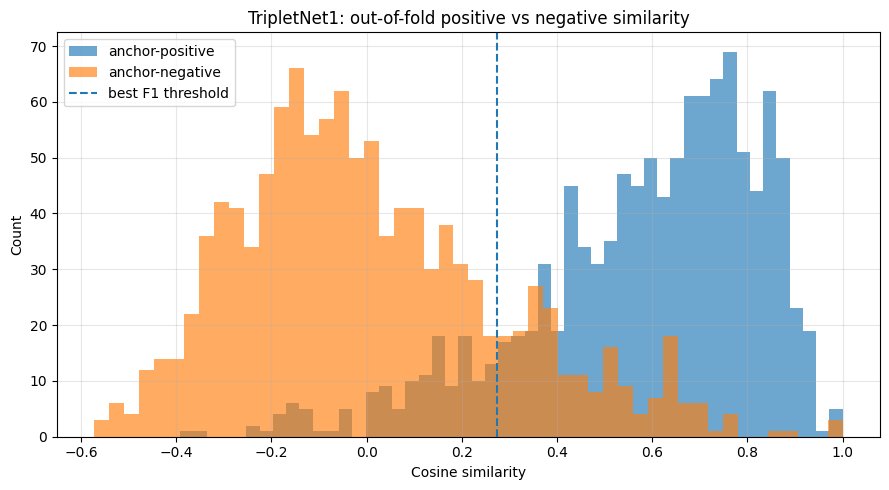

Saved figure: figures/model1/oof_margin_gap_distribution.png


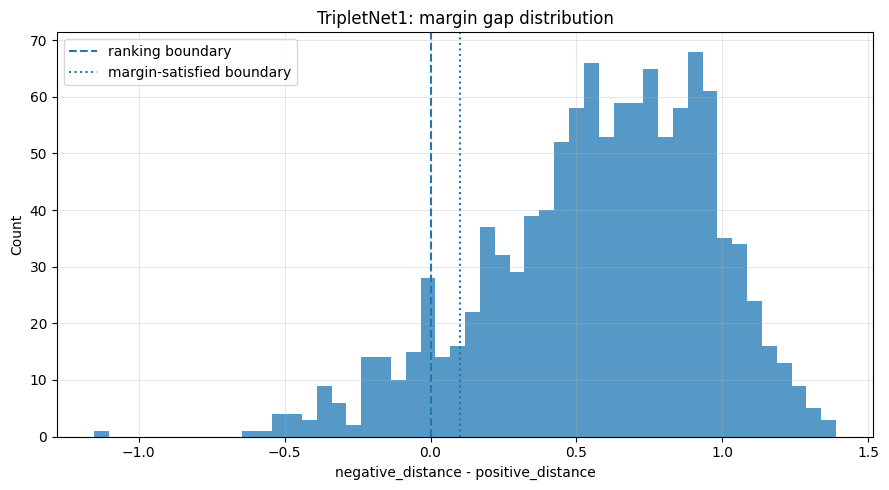

Saved figure: figures/model1/pair_threshold_analysis.png


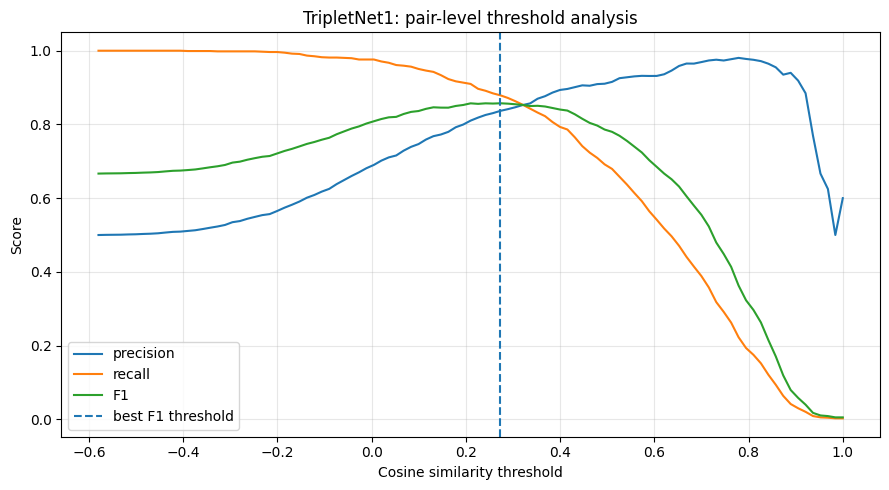

,fold,triplet_id,positive_similarity,negative_similarity,similarity_gap,positive_distance,negative_distance,margin_gap,ranking_correct,margin_satisfied
0,1,53,-0.152985,1.000000,-1.152985,1.152985,1.192093e-07,-1.152985,False,False
1,3,37,0.388390,1.000000,-0.611610,0.611610,0.000000e+00,-0.611610,False,False
2,3,179,0.108488,0.662989,-0.554501,0.891512,3.370110e-01,-0.554501,False,False
3,2,189,0.038124,0.569914,-0.531790,0.961876,4.300860e-01,-0.531790,False,False
4,3,63,0.013323,0.530360,-0.517037,0.986677,4.696405e-01,-0.517037,False,False
5,4,187,0.258660,0.765569,-0.506909,0.741340,2.344313e-01,-0.506909,False,False
6,1,177,0.141853,0.646951,-0.505098,0.858147,3.530487e-01,-0.505098,False,False
7,4,193,0.073898,0.551868,-0.477970,0.926102,4.481322e-01,-0.477970,False,False
8,1,99,-0.152728,0.320657,-0.473386,1.152728,6.793429e-01,-0.473386,False,False
9,1,98,0.221011,0.684648,-0.463638,0.778989,3.153516e-01,-0.463638,False,False


In [8]:

# 2) Triplet-level out-of-fold analysis: distances, gaps, threshold precision/recall.
triplet_summary = pd.DataFrame([{
    "model": MODEL_NAME,
    "best_margin": best_margin,
    "selection_metric": "validation_mrr",
    "best_fold": best_fold_result["fold"],
    "best_fold_val_mrr": best_fold_result["best_val_mrr"],
    "best_fold_val_acc": best_fold_result["best_val_acc"],
    "oof_triplets": len(oof_triplet_df),
    "ranking_accuracy": oof_triplet_df["ranking_correct"].mean(),
    "margin_satisfied_accuracy": oof_triplet_df["margin_satisfied"].mean(),
    "mean_positive_similarity": oof_triplet_df["positive_similarity"].mean(),
    "mean_negative_similarity": oof_triplet_df["negative_similarity"].mean(),
    "mean_similarity_gap": oof_triplet_df["similarity_gap"].mean(),
    "mean_positive_distance": oof_triplet_df["positive_distance"].mean(),
    "mean_negative_distance": oof_triplet_df["negative_distance"].mean(),
    "mean_margin_gap": oof_triplet_df["margin_gap"].mean(),
    "roc_auc": auc_metrics["roc_auc"],
    "average_precision": auc_metrics["average_precision"],
    "best_f1_threshold": best_threshold_row["threshold"],
    "best_threshold_precision": best_threshold_row["precision"],
    "best_threshold_recall": best_threshold_row["recall"],
    "best_threshold_f1": best_threshold_row["f1"],
}])
display(triplet_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(oof_triplet_df["positive_similarity"], bins=50, alpha=0.65, label="anchor-positive")
ax.hist(oof_triplet_df["negative_similarity"], bins=50, alpha=0.65, label="anchor-negative")
ax.axvline(float(best_threshold_row["threshold"]), linestyle="--", label="best F1 threshold")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.set_title(f"{MODEL_NAME}: out-of-fold positive vs negative similarity")
ax.grid(True, alpha=0.3)
ax.legend()
save_figure(fig, "oof_positive_negative_similarity.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(oof_triplet_df["margin_gap"], bins=50, alpha=0.75)
ax.axvline(0.0, linestyle="--", label="ranking boundary")
ax.axvline(best_margin, linestyle=":", label="margin-satisfied boundary")
ax.set_xlabel("negative_distance - positive_distance")
ax.set_ylabel("Count")
ax.set_title(f"{MODEL_NAME}: margin gap distribution")
ax.grid(True, alpha=0.3)
ax.legend()
save_figure(fig, "oof_margin_gap_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["precision"], label="precision")
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["recall"], label="recall")
ax.plot(threshold_metrics_df["threshold"], threshold_metrics_df["f1"], label="F1")
ax.axvline(float(best_threshold_row["threshold"]), linestyle="--", label="best F1 threshold")
ax.set_xlabel("Cosine similarity threshold")
ax.set_ylabel("Score")
ax.set_title(f"{MODEL_NAME}: pair-level threshold analysis")
ax.grid(True, alpha=0.3)
ax.legend()
save_figure(fig, "pair_threshold_analysis.png")
plt.show()

hardest_triplets = oof_triplet_df.sort_values("similarity_gap").head(20).reset_index(drop=True)
display(hardest_triplets[[
    "fold", "triplet_id", "positive_similarity", "negative_similarity", "similarity_gap",
    "positive_distance", "negative_distance", "margin_gap", "ranking_correct", "margin_satisfied"
]])


### 3. Retrieval metrics and qualitative nearest neighbours


In [9]:

# 3) Retrieval analysis: nearest-neighbour quality in the learned artist latent space.
@torch.inference_mode()
def encode_artists(model, artist_tensors: dict[str, torch.Tensor], batch_size: int = 256) -> pd.DataFrame:
    model.eval()
    artist_ids = sorted(map(str, artist_tensors.keys()))
    embedding_chunks = []
    for start in range(0, len(artist_ids), batch_size):
        batch_ids = artist_ids[start:start + batch_size]
        batch = torch.stack([artist_tensors[artist_id].float() for artist_id in batch_ids], dim=0).to(DEVICE)
        encoded = model.forward_once(batch).detach().cpu().float()
        encoded = F.normalize(encoded, dim=1, eps=1e-8)
        embedding_chunks.append(encoded.numpy())
    matrix = np.vstack(embedding_chunks)
    columns = [f"z_{i:03d}" for i in range(matrix.shape[1])]
    return pd.DataFrame(matrix, index=artist_ids, columns=columns)


def build_ground_truth_positive_sets(df: pd.DataFrame, available_ids: set[str], symmetric: bool = True) -> dict[str, set[str]]:
    positives = defaultdict(set)
    clean = df.copy()
    for col in TRIPLET_COLUMNS:
        clean[col] = clean[col].astype(str)
    for row in clean.itertuples(index=False):
        anchor = str(getattr(row, "anchor"))
        positive = str(getattr(row, "positive"))
        if anchor in available_ids and positive in available_ids and anchor != positive:
            positives[anchor].add(positive)
            if symmetric:
                positives[positive].add(anchor)
    return dict(positives)


def compute_retrieval_metrics(embedding_df: pd.DataFrame, positive_sets: dict[str, set[str]], ks=(1, 5, 10, 20)):
    artist_ids = embedding_df.index.astype(str).tolist()
    id_to_idx = {artist_id: idx for idx, artist_id in enumerate(artist_ids)}
    matrix = embedding_df.to_numpy(dtype=np.float32)
    matrix = matrix / np.maximum(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8)
    similarity = matrix @ matrix.T
    np.fill_diagonal(similarity, -np.inf)

    rows = []
    nearest_rows = []
    for anchor_id, positives in positive_sets.items():
        if anchor_id not in id_to_idx:
            continue
        positives = {p for p in positives if p in id_to_idx and p != anchor_id}
        if not positives:
            continue
        anchor_idx = id_to_idx[anchor_id]
        order = np.argsort(-similarity[anchor_idx])
        ranked_ids = [artist_ids[i] for i in order]
        ranked_positive_flags = np.array([candidate in positives for candidate in ranked_ids], dtype=bool)

        row = {
            "anchor": anchor_id,
            "num_positives": len(positives),
        }
        for k in ks:
            topk_flags = ranked_positive_flags[:k]
            hits = int(topk_flags.sum())
            row[f"precision@{k}"] = hits / k
            row[f"recall@{k}"] = hits / len(positives)
            row[f"hit@{k}"] = float(hits > 0)

        positive_ranks = np.flatnonzero(ranked_positive_flags) + 1
        row["mrr"] = 1.0 / positive_ranks[0] if len(positive_ranks) else 0.0
        if len(positive_ranks):
            precisions_at_hits = []
            for rank in positive_ranks:
                precisions_at_hits.append(ranked_positive_flags[:rank].sum() / rank)
            row["average_precision"] = float(np.sum(precisions_at_hits) / len(positives))
        else:
            row["average_precision"] = 0.0
        rows.append(row)

        for rank, candidate_idx in enumerate(order[:10], start=1):
            candidate_id = artist_ids[candidate_idx]
            nearest_rows.append({
                "anchor": anchor_id,
                "rank": rank,
                "candidate": candidate_id,
                "cosine_similarity": float(similarity[anchor_idx, candidate_idx]),
                "is_ground_truth_positive": candidate_id in positives,
            })

    metric_df = pd.DataFrame(rows)
    nearest_df = pd.DataFrame(nearest_rows)
    if metric_df.empty:
        summary = pd.DataFrame()
    else:
        summary = metric_df.drop(columns=["anchor"]).mean(numeric_only=True).to_frame("mean").T
        summary.insert(0, "model", MODEL_NAME)
        summary.insert(1, "checkpoint", str(best_checkpoint_path))
    return metric_df, summary, nearest_df

artist_embedding_df = encode_artists(best_model, artist_averages)
positive_sets = build_ground_truth_positive_sets(filtered_triplet_df, set(artist_embedding_df.index), symmetric=True)
retrieval_metric_df, retrieval_summary_df, nearest_neighbors_df = compute_retrieval_metrics(
    artist_embedding_df,
    positive_sets,
    ks=(1, 5, 10, 20),
)

print(f"Encoded artists: {len(artist_embedding_df)}")
print(f"Artists with at least one ground-truth positive: {len(positive_sets)}")
display(retrieval_summary_df)
display(retrieval_metric_df.sort_values("average_precision", ascending=False).head(10))
display(retrieval_metric_df.sort_values("average_precision", ascending=True).head(10))
display(nearest_neighbors_df.head(50))


Encoded artists: 3892
Artists with at least one ground-truth positive: 2795


,model,checkpoint,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
mean,TripletNet1,checkpoints/TripletNet1/TripletNet1_margin_0.1...,9.785331,0.27585,0.031009,0.27585,0.211234,0.114468,0.565653,0.179821,0.189251,0.684436,0.145599,0.298698,0.782826,0.40553,0.182581


,anchor,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
2755,033b25ca-ccf9-4b6b-b818-f3f5271476c6,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
1905,ae24a315-4619-42a9-a7ca-df70a87b14a8,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
2417,c9b8ac6a-f57c-4b2a-ab04-0025c22c6e2f,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
2686,eba5cff8-c63b-40b5-9588-b8e840d1a694,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
2684,83c1abfd-352b-453a-9988-362dc802826c,2,1.0,0.50,1.0,0.4,1.00,1.0,0.2,1.0,1.0,0.10,1.00,1.0,1.0,1.000000
1857,babb741d-c3ce-4a89-84f4-55d1042251d2,2,1.0,0.50,1.0,0.4,1.00,1.0,0.2,1.0,1.0,0.10,1.00,1.0,1.0,1.000000
2783,188c7bc1-ff29-4c30-b204-8406e58ea273,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
1854,f3bb45c8-dcb3-4358-ab21-645e6d0935e4,1,1.0,1.00,1.0,0.2,1.00,1.0,0.1,1.0,1.0,0.05,1.00,1.0,1.0,1.000000
2640,54076e38-209b-4b75-b766-1138a32cb62e,2,1.0,0.50,1.0,0.4,1.00,1.0,0.2,1.0,1.0,0.10,1.00,1.0,1.0,1.000000
1057,508f4f83-26dc-4d21-98d9-1a8c04d5ad4a,20,1.0,0.05,1.0,1.0,0.25,1.0,1.0,0.5,1.0,0.85,0.85,1.0,1.0,0.859535


,anchor,num_positives,precision@1,recall@1,hit@1,precision@5,recall@5,hit@5,precision@10,recall@10,hit@10,precision@20,recall@20,hit@20,mrr,average_precision
1382,c60f9fb1-b519-4c70-ba0c-d89b9e96aff1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000598,0.000598
2000,6f49184a-8757-48d7-9145-f773ea572188,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000607,0.000607
1381,67e73830-4d24-4631-928b-47d32e9eac6b,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000605,0.000677
2020,1cf1db8f-06bc-4c02-a608-4fc7980bbfcc,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000759,0.000759
1250,51ff6576-95ff-4e02-a0cf-fad3b39c0b8d,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000924,0.000924
2372,3df914b9-e0bc-493c-875a-c412f84ecdad,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000930,0.000930
2546,ab926775-85a9-4b30-a712-87a8818ba2c6,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000934,0.001017
2556,759a0fd2-0f12-4414-a90b-9bb9f20dfb4d,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001041,0.001041
425,f58654bf-c6e3-45b6-9fcc-62cf8f0021b2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001060,0.001060
2411,923ddf37-8f58-4fce-96b0-f47c0d030cb6,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001098,0.001098


,anchor,rank,candidate,cosine_similarity,is_ground_truth_positive
0,acb5a55d-2e39-4098-962e-acbc68adc663,1,614b892d-4f1a-4d1a-b382-dcc17ee159bc,0.812902,False
1,acb5a55d-2e39-4098-962e-acbc68adc663,2,2017acdf-899e-4db3-a237-06696d8af58b,0.784935,True
2,acb5a55d-2e39-4098-962e-acbc68adc663,3,e0827234-3be3-4973-be59-1aa9575b9c76,0.781860,True
3,acb5a55d-2e39-4098-962e-acbc68adc663,4,171cbc8f-8ab3-4aec-9916-f0bdbe26bb79,0.761123,False
4,acb5a55d-2e39-4098-962e-acbc68adc663,5,802d37d5-0aaa-492e-b366-99f75e5a196f,0.747876,False
5,acb5a55d-2e39-4098-962e-acbc68adc663,6,1144f22d-fb1f-41a7-9822-05dab5edff25,0.744645,False
6,acb5a55d-2e39-4098-962e-acbc68adc663,7,0497bb2c-f4c1-4cbd-9811-9a1efe8854e3,0.741849,False
7,acb5a55d-2e39-4098-962e-acbc68adc663,8,ef32e381-8413-40a0-b7ad-1ca7bf514ee8,0.707222,False
8,acb5a55d-2e39-4098-962e-acbc68adc663,9,98af45d8-fff7-48e4-afa9-48dc5fd18581,0.704910,False
9,acb5a55d-2e39-4098-962e-acbc68adc663,10,eeacb319-8d4c-48e0-80a0-944e71c375bf,0.704590,True


### 4. Latent-space visualisation and metadata consistency


,artist_id,z_000,z_001,z_002,z_003,z_004,z_005,z_006,z_007,z_008,...,z_250,z_251,z_252,z_253,z_254,z_255,genre,broad_genre,country,metadata_source
0,0004537a-4b12-43eb-a023-04009e738d2e,0.017439,0.048552,-0.036766,0.017298,0.051293,0.033988,-0.071797,0.096381,0.034430,...,-0.022802,-0.048902,-0.043857,0.090346,-0.057974,0.046565,vocal,others,USA,../data/metadata/artists_genre_country.csv
1,0011f816-f0a8-4603-b82d-6f021d214672,-0.000956,-0.037872,-0.091678,-0.076359,0.071279,-0.068613,0.006715,-0.009291,0.045380,...,-0.014449,-0.062118,-0.034976,0.112781,-0.121445,0.077802,jazz,jazz,USA,../data/metadata/artists_genre_country.csv
2,0039c7ae-e1a7-4a7d-9b49-0cbc716821a6,-0.050521,-0.101904,-0.079148,-0.013967,-0.055687,-0.136633,0.060362,-0.070409,-0.055137,...,0.060300,-0.002114,-0.043691,-0.095516,-0.084815,-0.009468,rock,rock,USA,../data/metadata/artists_genre_country.csv
3,003f3a74-7595-4da7-b46b-19a8f8e9a1b5,0.051441,0.092665,-0.080508,0.039409,-0.105295,0.085495,0.036760,0.036998,-0.023829,...,-0.091991,-0.019057,0.060074,0.019500,0.045176,0.032748,pop,pop,Italy,../data/metadata/artists_genre_country.csv
4,00467da8-2a92-498f-8b10-a80889bcded7,-0.042184,0.017977,-0.058708,-0.084187,0.131738,0.017066,0.015065,-0.047164,-0.033126,...,-0.005345,0.017169,-0.026567,-0.060003,-0.017669,0.014233,rock,rock,UK,../data/metadata/artists_genre_country.csv


Saved figure: figures/model1/pca_country_latent_space.png


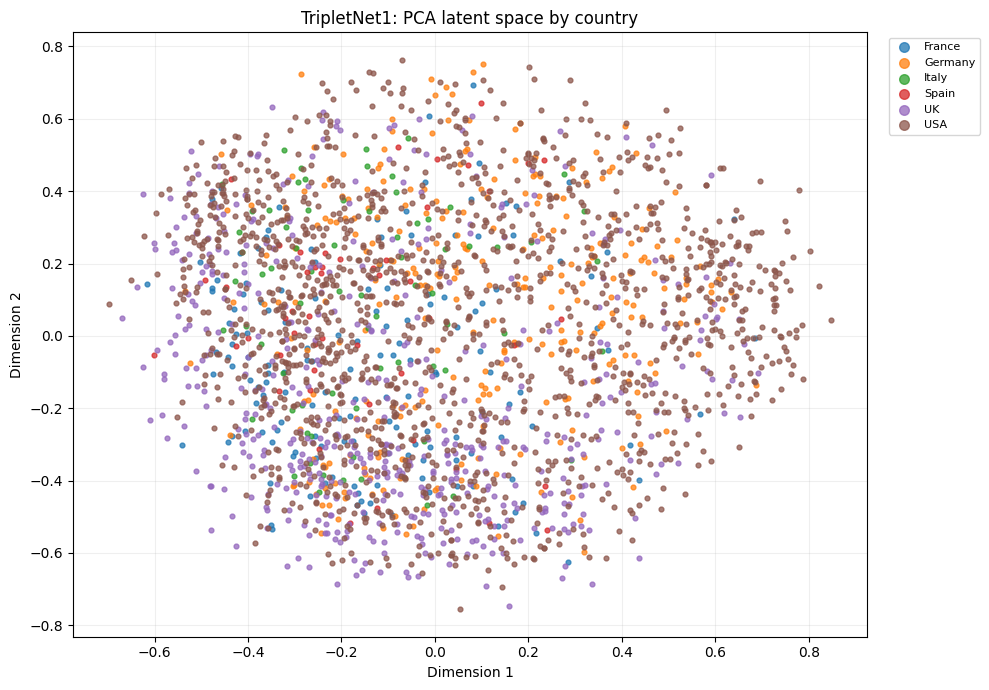

Saved figure: figures/model1/tsne_country_latent_space.png


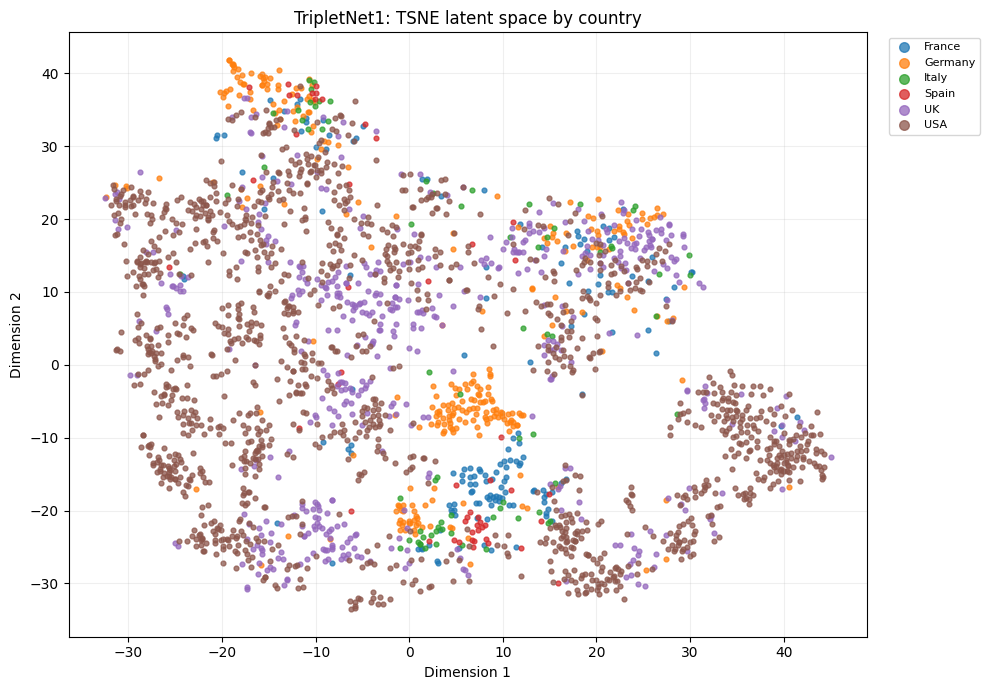

Saved figure: figures/model1/pca_genre_latent_space.png


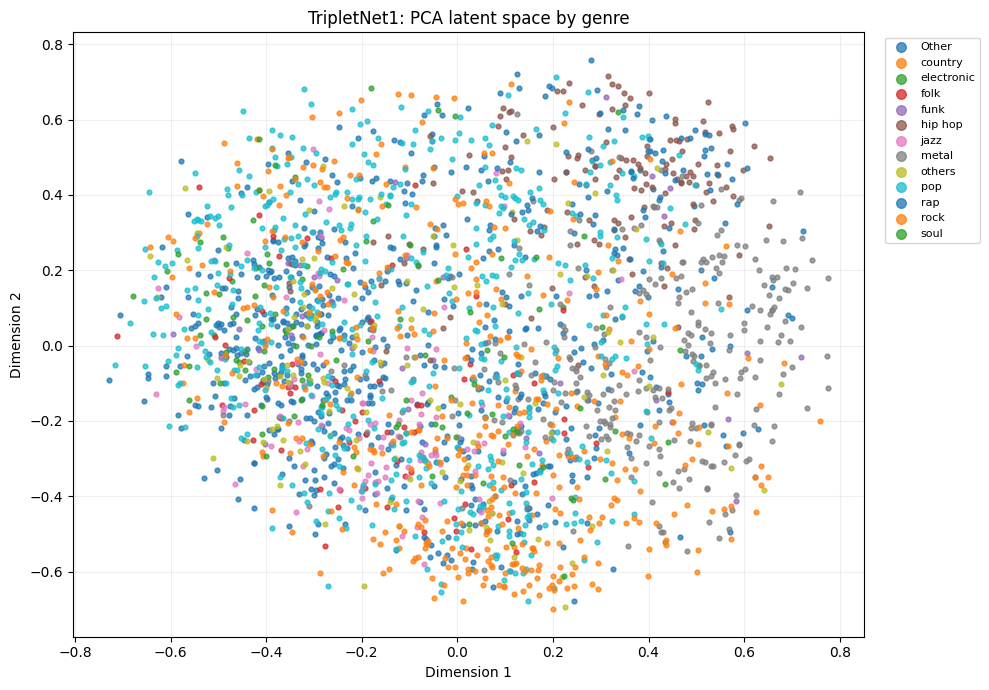

Saved figure: figures/model1/tsne_genre_latent_space.png


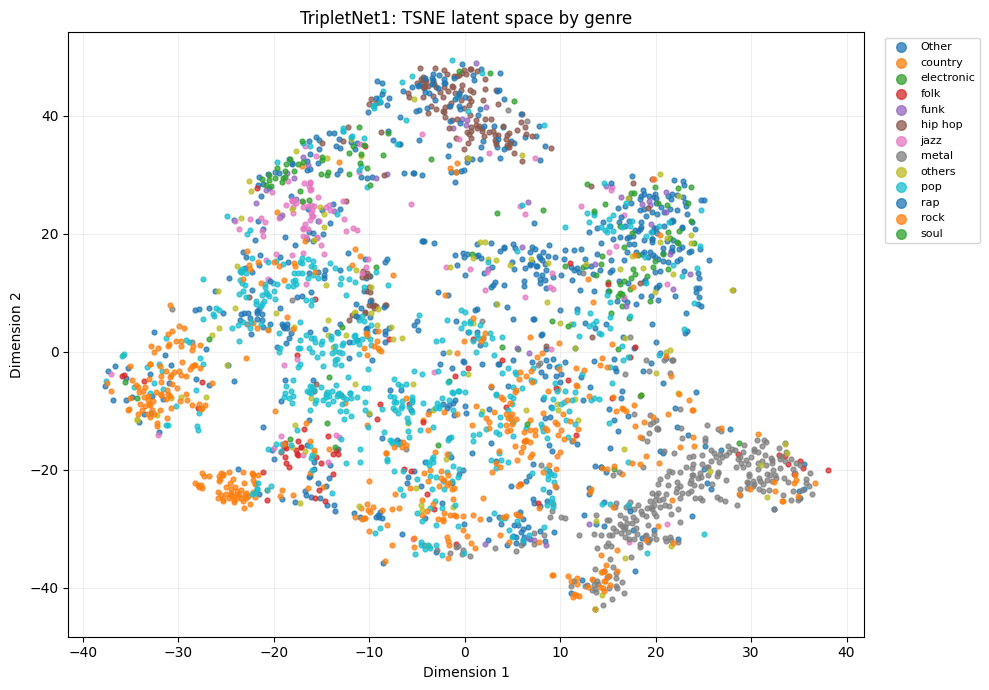

,label_column,label,n_artists,mean_intra_similarity,std_intra_similarity,mean_inter_similarity,std_inter_similarity,intra_minus_inter
0,country,Spain,93,0.251839,0.281232,0.020313,0.217685,0.231527
1,country,Germany,437,0.200215,0.281940,-0.002813,0.220103,0.203029
2,country,France,247,0.207191,0.261662,0.029209,0.221665,0.177982
3,country,Italy,99,0.194098,0.265357,0.026235,0.227071,0.167863
4,country,UK,770,0.134896,0.266430,0.012296,0.241096,0.122599
5,country,USA,2212,0.018914,0.265486,-0.010335,0.224355,0.029249


,label_column,label,n_artists,mean_intra_similarity,std_intra_similarity,mean_inter_similarity,std_inter_similarity,intra_minus_inter
0,genre,neue deutsche harte,5,0.784828,0.086616,-0.179576,0.168224,0.964404
1,genre,classic schlager,10,0.799388,0.080037,-0.014499,0.213452,0.813888
2,genre,progressive house,5,0.774762,0.103257,-0.036490,0.116576,0.811252
3,genre,banjo,6,0.731858,0.088001,-0.011306,0.216622,0.743164
4,genre,jam band,8,0.734951,0.135070,-0.004224,0.230502,0.739175
5,genre,chiptune,5,0.733254,0.103621,0.040273,0.218171,0.692981
6,genre,acid house,5,0.666558,0.074216,-0.014764,0.183971,0.681321
7,genre,deep euro house,5,0.797844,0.030791,0.122155,0.252275,0.675689
8,genre,chanson,6,0.653751,0.137476,-0.009342,0.209816,0.663093
9,genre,contemporary r&b,11,0.651172,0.216211,0.002169,0.257827,0.649003


In [10]:

# 4) Metadata-aware latent-space analysis: t-SNE/PCA and group similarity.
def load_artist_metadata() -> pd.DataFrame:
    candidate_paths = [
        Path("../data/metadata/artists_genre_country.csv"),
        Path("../data/metadata/artists_genre_country_major_genres.csv"),
        Path("../data/metadata/artists.csv"),
        Path("../data/metadata/artists_metadata.csv"),
        Path("../data/metadata/metadata.csv"),
    ]
    for path in candidate_paths:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df.columns = [str(col).strip() for col in df.columns]
        lower_map = {col.lower(): col for col in df.columns}
        id_col = None
        for candidate in ["musicbrainz_id", "artist_id", "id", "mbid"]:
            if candidate in lower_map:
                id_col = lower_map[candidate]
                break
        if id_col is None:
            print(f"Skipping metadata file without artist id column: {path}")
            continue
        df = df.rename(columns={id_col: "artist_id"})
        df["artist_id"] = df["artist_id"].astype(str)
        df["metadata_source"] = str(path)
        return df
    return pd.DataFrame()


def infer_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower_map = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None

artist_metadata_df = load_artist_metadata()
if artist_metadata_df.empty:
    print("No metadata file found. t-SNE and intra/inter-group similarity by country/genre are skipped.")
else:
    country_col = infer_column(artist_metadata_df, ["country", "nationality", "artist_country"])
    genre_col = infer_column(artist_metadata_df, ["genre", "genres", "general_genre", "main_genre", "music_genre"])
    name_col = infer_column(artist_metadata_df, ["name", "artist", "artist_name"])

    metadata_embedding_df = artist_embedding_df.reset_index(names="artist_id").merge(artist_metadata_df, on="artist_id", how="left")
    display(metadata_embedding_df.head())

    projection_cache: dict[tuple[str, int], pd.DataFrame] = {}

    def build_shared_projection(method: str = "tsne", max_points: int = 2500) -> pd.DataFrame | None:
        method = method.lower()
        cache_key = (method, max_points)
        if cache_key in projection_cache:
            return projection_cache[cache_key].copy()

        feature_cols = [col for col in metadata_embedding_df.columns if col.startswith("z_")]
        if not feature_cols:
            print("No latent embedding columns found for projection.")
            return None

        projection_df = metadata_embedding_df.dropna(subset=feature_cols).copy()
        if len(projection_df) > max_points:
            projection_df = projection_df.sample(max_points, random_state=SEED).copy()
        if len(projection_df) < 2:
            print(f"{method.upper()} skipped: at least two artists are required.")
            return None

        x = projection_df[feature_cols].to_numpy(dtype=np.float32)
        try:
            from sklearn.decomposition import PCA
            if method == "pca":
                coords = PCA(n_components=2, random_state=SEED).fit_transform(x)
            elif method == "tsne":
                from sklearn.manifold import TSNE
                pca_components = min(50, x.shape[1], len(projection_df) - 1)
                x_for_tsne = x
                if pca_components >= 2 and pca_components < x.shape[1]:
                    x_for_tsne = PCA(n_components=pca_components, random_state=SEED).fit_transform(x)
                x_for_tsne = x_for_tsne / np.maximum(np.linalg.norm(x_for_tsne, axis=1, keepdims=True), 1e-8)
                perplexity = min(40, max(5, (len(projection_df) - 1) // 3))
                perplexity = min(perplexity, max(1, len(projection_df) - 1))
                kwargs = dict(n_components=2, random_state=SEED, metric="cosine", init="pca", perplexity=perplexity)
                try:
                    coords = TSNE(max_iter=1000, **kwargs).fit_transform(x_for_tsne)
                except TypeError:
                    coords = TSNE(n_iter=1000, **kwargs).fit_transform(x_for_tsne)
            else:
                raise ValueError(f"Unsupported projection method: {method}")
        except Exception as exc:
            print(f"{method.upper()} skipped: {exc}")
            return None

        projection_df["dim_1"] = coords[:, 0]
        projection_df["dim_2"] = coords[:, 1]
        projection_cache[cache_key] = projection_df.copy()
        return projection_df

    def plot_latent_projection(label_col: str | None, method: str = "tsne", max_points: int = 2500):
        if label_col is None or label_col not in metadata_embedding_df.columns:
            print(f"No usable label column for {method.upper()} plot.")
            return None
        plot_df = build_shared_projection(method=method, max_points=max_points)
        if plot_df is None or plot_df.empty:
            return None

        labels = plot_df[label_col].fillna("Unknown").astype(str)
        top_labels = labels.value_counts().head(12).index.tolist()
        plot_df["plot_label"] = np.where(labels.isin(top_labels), labels, "Other")

        fig, ax = plt.subplots(figsize=(10, 7))
        for label, group in plot_df.groupby("plot_label"):
            ax.scatter(group["dim_1"], group["dim_2"], s=12, alpha=0.75, label=label)
        ax.set_title(f"{MODEL_NAME}: {method.upper()} latent space by {label_col}")
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.grid(True, alpha=0.2)
        ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        save_figure(fig, f"{method}_{label_col}_latent_space.png")
        plt.show()
        return plot_df

    pca_country_df = plot_latent_projection(country_col, method="pca")
    tsne_country_df = plot_latent_projection(country_col, method="tsne")
    if genre_col is not None and genre_col != country_col:
        pca_genre_df = plot_latent_projection(genre_col, method="pca")
        tsne_genre_df = plot_latent_projection(genre_col, method="tsne")

    def group_similarity_summary(label_col: str | None, min_group_size: int = 5, max_pairs: int = 20000) -> pd.DataFrame:
        if label_col is None or label_col not in metadata_embedding_df.columns:
            return pd.DataFrame()
        df = metadata_embedding_df.dropna(subset=[label_col]).copy()
        feature_cols = [col for col in df.columns if col.startswith("z_")]
        matrix = df[feature_cols].to_numpy(dtype=np.float32)
        matrix = matrix / np.maximum(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8)
        labels = df[label_col].astype(str).to_numpy()
        rng = np.random.default_rng(SEED)
        rows = []
        for label in sorted(pd.Series(labels).dropna().unique()):
            idx = np.flatnonzero(labels == label)
            other_idx = np.flatnonzero(labels != label)
            if len(idx) < min_group_size or len(other_idx) == 0:
                continue

            n_possible = len(idx) * (len(idx) - 1) // 2
            n_pairs = min(max_pairs, n_possible)
            if n_pairs <= 0:
                continue
            i = rng.choice(idx, size=n_pairs, replace=True)
            j = rng.choice(idx, size=n_pairs, replace=True)
            keep = i != j
            i, j = i[keep], j[keep]
            if len(i) == 0:
                continue
            intra = np.sum(matrix[i] * matrix[j], axis=1)

            inter_i = rng.choice(idx, size=len(i), replace=True)
            inter_j = rng.choice(other_idx, size=len(i), replace=True)
            inter = np.sum(matrix[inter_i] * matrix[inter_j], axis=1)

            rows.append({
                "label_column": label_col,
                "label": label,
                "n_artists": len(idx),
                "mean_intra_similarity": float(np.mean(intra)),
                "std_intra_similarity": float(np.std(intra)),
                "mean_inter_similarity": float(np.mean(inter)),
                "std_inter_similarity": float(np.std(inter)),
                "intra_minus_inter": float(np.mean(intra) - np.mean(inter)),
            })
        return pd.DataFrame(rows).sort_values("intra_minus_inter", ascending=False).reset_index(drop=True)

    country_similarity_df = group_similarity_summary(country_col)
    genre_similarity_df = group_similarity_summary(genre_col)
    if not country_similarity_df.empty:
        display(country_similarity_df)
    if not genre_similarity_df.empty:
        display(genre_similarity_df)


### 5. Error analysis and exported result files


In [11]:

# 5) Error analysis and artifact export.
threshold = float(best_threshold_row["threshold"])
positive_pair_df = oof_triplet_df[["fold", "triplet_id", "positive_similarity"]].rename(
    columns={"positive_similarity": "similarity"}
)
positive_pair_df["pair_label"] = 1
positive_pair_df["predicted_positive"] = positive_pair_df["similarity"] >= threshold

negative_pair_df = oof_triplet_df[["fold", "triplet_id", "negative_similarity"]].rename(
    columns={"negative_similarity": "similarity"}
)
negative_pair_df["pair_label"] = 0
negative_pair_df["predicted_positive"] = negative_pair_df["similarity"] >= threshold

pair_error_df = pd.concat([positive_pair_df, negative_pair_df], ignore_index=True)
pair_error_df["error_type"] = np.select(
    [
        (pair_error_df["pair_label"] == 1) & (~pair_error_df["predicted_positive"]),
        (pair_error_df["pair_label"] == 0) & (pair_error_df["predicted_positive"]),
    ],
    ["false_negative_positive_pair", "false_positive_negative_pair"],
    default="correct",
)

false_positive_pairs = pair_error_df[pair_error_df["error_type"] == "false_positive_negative_pair"].sort_values("similarity", ascending=False)
false_negative_pairs = pair_error_df[pair_error_df["error_type"] == "false_negative_positive_pair"].sort_values("similarity", ascending=True)

print(f"Threshold used for pair error analysis: {threshold:.3f}")
print(f"False-positive negative pairs: {len(false_positive_pairs)}")
print(f"False-negative positive pairs: {len(false_negative_pairs)}")
display(false_positive_pairs.head(20))
display(false_negative_pairs.head(20))

# Save everything needed for the thesis/results section.
oof_triplet_path = ANALYSIS_DIR / f"{MODEL_NAME}_oof_triplet_predictions.csv"
threshold_path = ANALYSIS_DIR / f"{MODEL_NAME}_threshold_metrics.csv"
triplet_summary_path = ANALYSIS_DIR / f"{MODEL_NAME}_triplet_summary.csv"
retrieval_metric_path = ANALYSIS_DIR / f"{MODEL_NAME}_retrieval_per_anchor.csv"
retrieval_summary_path = ANALYSIS_DIR / f"{MODEL_NAME}_retrieval_summary.csv"
nearest_neighbors_path = ANALYSIS_DIR / f"{MODEL_NAME}_nearest_neighbors.csv"
pair_error_path = ANALYSIS_DIR / f"{MODEL_NAME}_pair_error_analysis.csv"
artist_embedding_path = ANALYSIS_DIR / f"{MODEL_NAME}_artist_latent_embeddings.csv"

oof_triplet_df.to_csv(oof_triplet_path, index=False)
threshold_metrics_df.to_csv(threshold_path, index=False)
triplet_summary.to_csv(triplet_summary_path, index=False)
retrieval_metric_df.to_csv(retrieval_metric_path, index=False)
retrieval_summary_df.to_csv(retrieval_summary_path, index=False)
nearest_neighbors_df.to_csv(nearest_neighbors_path, index=False)
pair_error_df.to_csv(pair_error_path, index=False)
artist_embedding_df.reset_index(names="artist_id").to_csv(artist_embedding_path, index=False)

if "country_similarity_df" in globals() and isinstance(country_similarity_df, pd.DataFrame) and not country_similarity_df.empty:
    country_similarity_df.to_csv(ANALYSIS_DIR / f"{MODEL_NAME}_country_similarity_summary.csv", index=False)
if "genre_similarity_df" in globals() and isinstance(genre_similarity_df, pd.DataFrame) and not genre_similarity_df.empty:
    genre_similarity_df.to_csv(ANALYSIS_DIR / f"{MODEL_NAME}_genre_similarity_summary.csv", index=False)

print("Saved analysis artifacts to:")
for path in [
    oof_triplet_path,
    threshold_path,
    triplet_summary_path,
    retrieval_metric_path,
    retrieval_summary_path,
    nearest_neighbors_path,
    pair_error_path,
    artist_embedding_path,
]:
    print(" -", path)


Threshold used for pair error analysis: 0.273
False-positive negative pairs: 194
False-negative positive pairs: 137


,fold,triplet_id,similarity,pair_label,predicted_positive,error_type
1461,2,101,1.000000,0,True,false_positive_negative_pair
1632,3,37,1.000000,0,True,false_positive_negative_pair
1185,1,53,1.000000,0,True,false_positive_negative_pair
1409,2,49,0.878071,0,True,false_positive_negative_pair
1986,4,173,0.873623,0,True,false_positive_negative_pair
1430,2,70,0.771789,0,True,false_positive_negative_pair
2000,4,187,0.765569,0,True,false_positive_negative_pair
1750,3,155,0.753492,0,True,false_positive_negative_pair
2236,5,207,0.751146,0,True,false_positive_negative_pair
1769,3,174,0.722692,0,True,false_positive_negative_pair


,fold,triplet_id,similarity,pair_label,predicted_positive,error_type
103,1,103,-0.391692,1,False,false_negative_positive_pair
671,3,208,-0.338117,1,False,false_negative_positive_pair
1113,5,216,-0.241439,1,False,false_negative_positive_pair
670,3,207,-0.229539,1,False,false_negative_positive_pair
44,1,44,-0.200404,1,False,false_negative_positive_pair
24,1,24,-0.185870,1,False,false_negative_positive_pair
336,2,108,-0.179505,1,False,false_negative_positive_pair
805,4,124,-0.172039,1,False,false_negative_positive_pair
426,2,198,-0.169413,1,False,false_negative_positive_pair
396,2,168,-0.166212,1,False,false_negative_positive_pair


Saved analysis artifacts to:
 - checkpoints/TripletNet1/analysis/TripletNet1_oof_triplet_predictions.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_threshold_metrics.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_triplet_summary.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_retrieval_per_anchor.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_retrieval_summary.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_nearest_neighbors.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_pair_error_analysis.csv
 - checkpoints/TripletNet1/analysis/TripletNet1_artist_latent_embeddings.csv
